In [5]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize']=14,8
RANDOM_SEED=42
LABELS=["Normal","Fraud"]

In [9]:
from google.colab import files
upload=files.upload()

Saving creditcard.csv to creditcard.csv


In [10]:
data=pd.read_csv('creditcard.csv',sep=',')
data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [12]:
data.isnull().values.any()

np.False_

/tmp/ipykernel_1521/1725262268.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort = True)


Text(0, 0.5, 'Frequency')

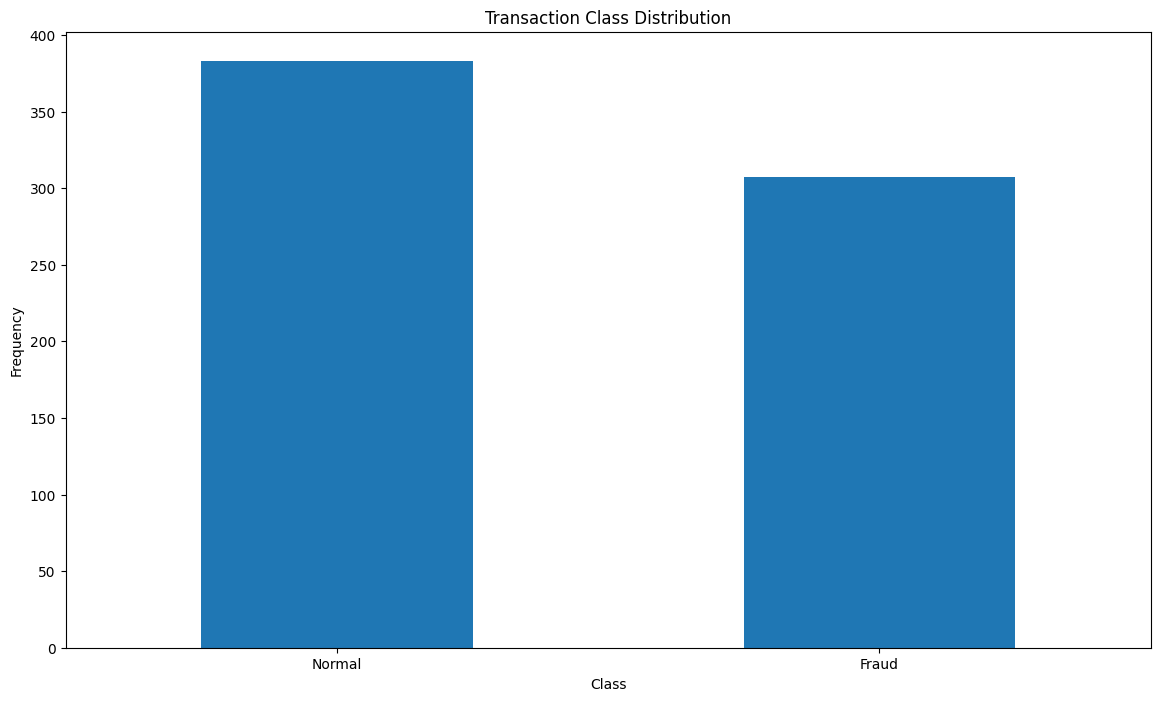

In [13]:
count_classes = pd.value_counts(data['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [14]:
fraud=data[data['Class']==1]
normal=data[data['Class']==0]
print(fraud.shape,normal.shape)

(307, 16) (383, 16)


In [15]:
fraud.describe()
fraud['A2'].describe()

,A2
count,307.000000
mean,33.706482
std,12.768886
min,13.750000
25%,23.210000
50%,30.670000
75%,41.330000
max,76.750000


In [17]:
normal.A2.describe()

,A2
count,383.000000
mean,29.854230
std,10.779092
min,15.170000
25%,22.125000
50%,27.670000
75%,34.790000
max,80.250000


In [20]:
print(fraud['A2'].describe())
print(normal['A2'].describe())

count    307.000000
mean      33.706482
std       12.768886
min       13.750000
25%       23.210000
50%       30.670000
75%       41.330000
max       76.750000
Name: A2, dtype: float64
count    383.000000
mean      29.854230
std       10.779092
min       15.170000
25%       22.125000
50%       27.670000
75%       34.790000
max       80.250000
Name: A2, dtype: float64


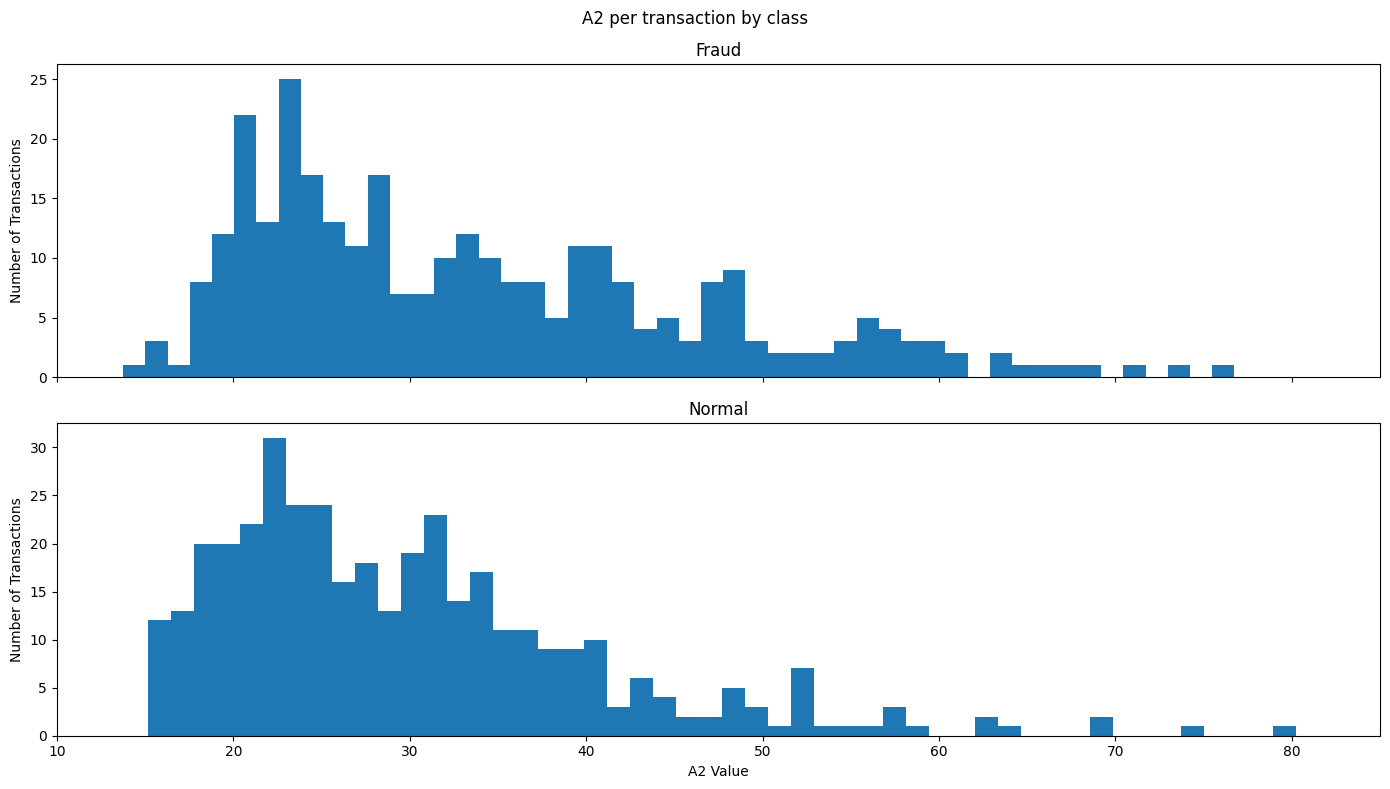

In [21]:
import matplotlib.pyplot as plt

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

f.suptitle('A2 per transaction by class')

bins = 50

# Fraud
ax1.hist(fraud['A2'], bins=bins)
ax1.set_title('Fraud')
ax1.set_ylabel('Number of Transactions')

# Normal
ax2.hist(normal['A2'], bins=bins)
ax2.set_title('Normal')
ax2.set_xlabel('A2 Value')
ax2.set_ylabel('Number of Transactions')

# A2 is approximately 14–80, so use an appropriate range
plt.xlim(10, 85)

plt.tight_layout()
plt.show()

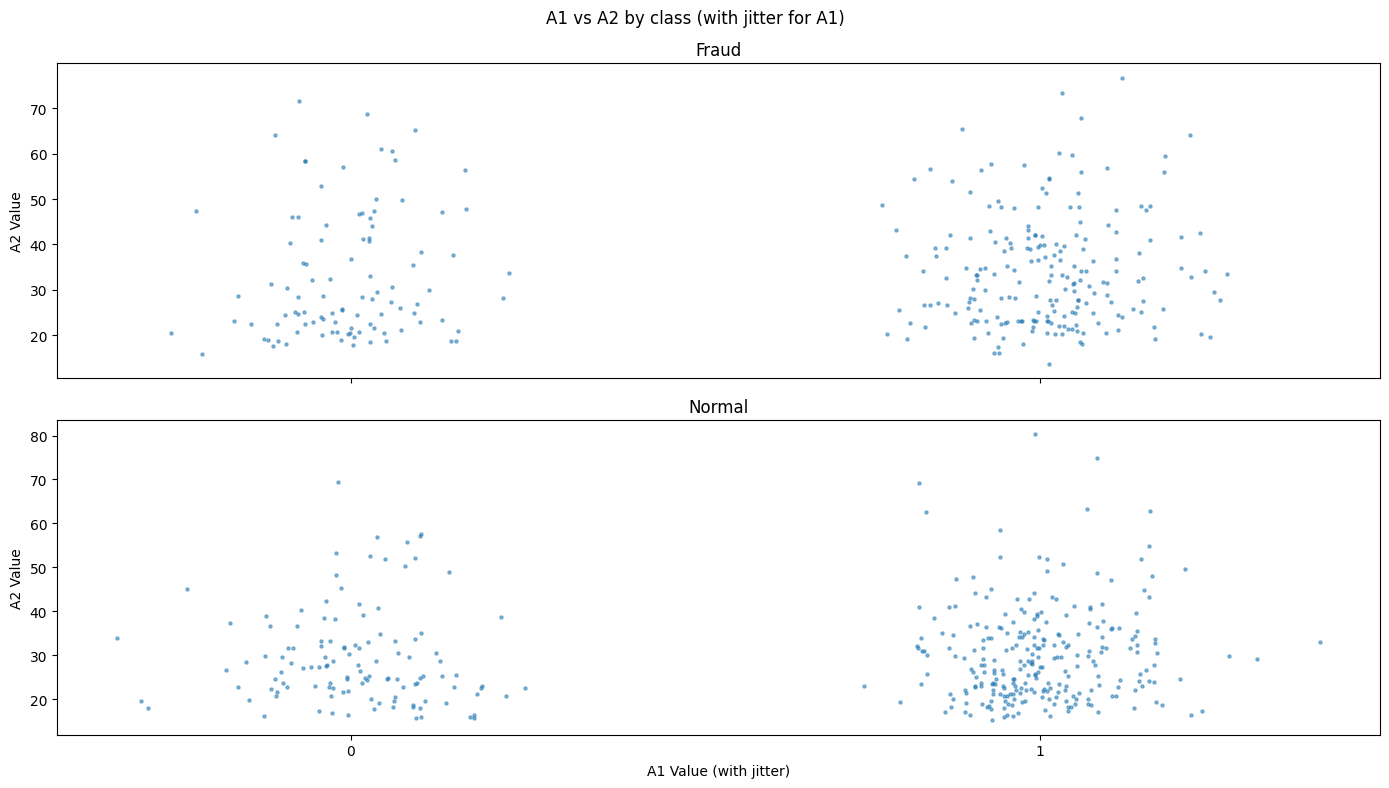

In [25]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

f.suptitle('A1 vs A2 by class (with jitter for A1)')

# Adding a small amount of jitter to A1 for better visualization of discrete values
f_jitter = fraud['A1'] + np.random.normal(0, 0.1, fraud['A1'].shape)
n_jitter = normal['A1'] + np.random.normal(0, 0.1, normal['A1'].shape)

# Fraud
ax1.scatter(f_jitter, fraud['A2'], s=5, alpha=0.5)
ax1.set_title('Fraud')
ax1.set_ylabel('A2 Value')
ax1.set_xticks([0, 1]) # Assuming A1 is binary 0 or 1
ax1.set_xticklabels(['0', '1'])

# Normal
ax2.scatter(n_jitter, normal['A2'], s=5, alpha=0.5)
ax2.set_title('Normal')
ax2.set_xlabel('A1 Value (with jitter)')
ax2.set_ylabel('A2 Value')
ax2.set_xticks([0, 1]) # Assuming A1 is binary 0 or 1
ax2.set_xticklabels(['0', '1'])

plt.tight_layout()
plt.show()

In [27]:
data=data.sample(frac=0.1,random_state=1)
data.shape

(7, 16)

In [28]:
Fraud = data[data['Class']==1]
Valid = data[data['Class']==0]
outlier_fraction = len(Fraud)/float(len(Valid))
print(outlier_fraction)
print("Fraud Cases : {}".format(len(Fraud)))
print("Valid Cases : {}".format(len(Valid)))

6.0
Fraud Cases : 6
Valid Cases : 1


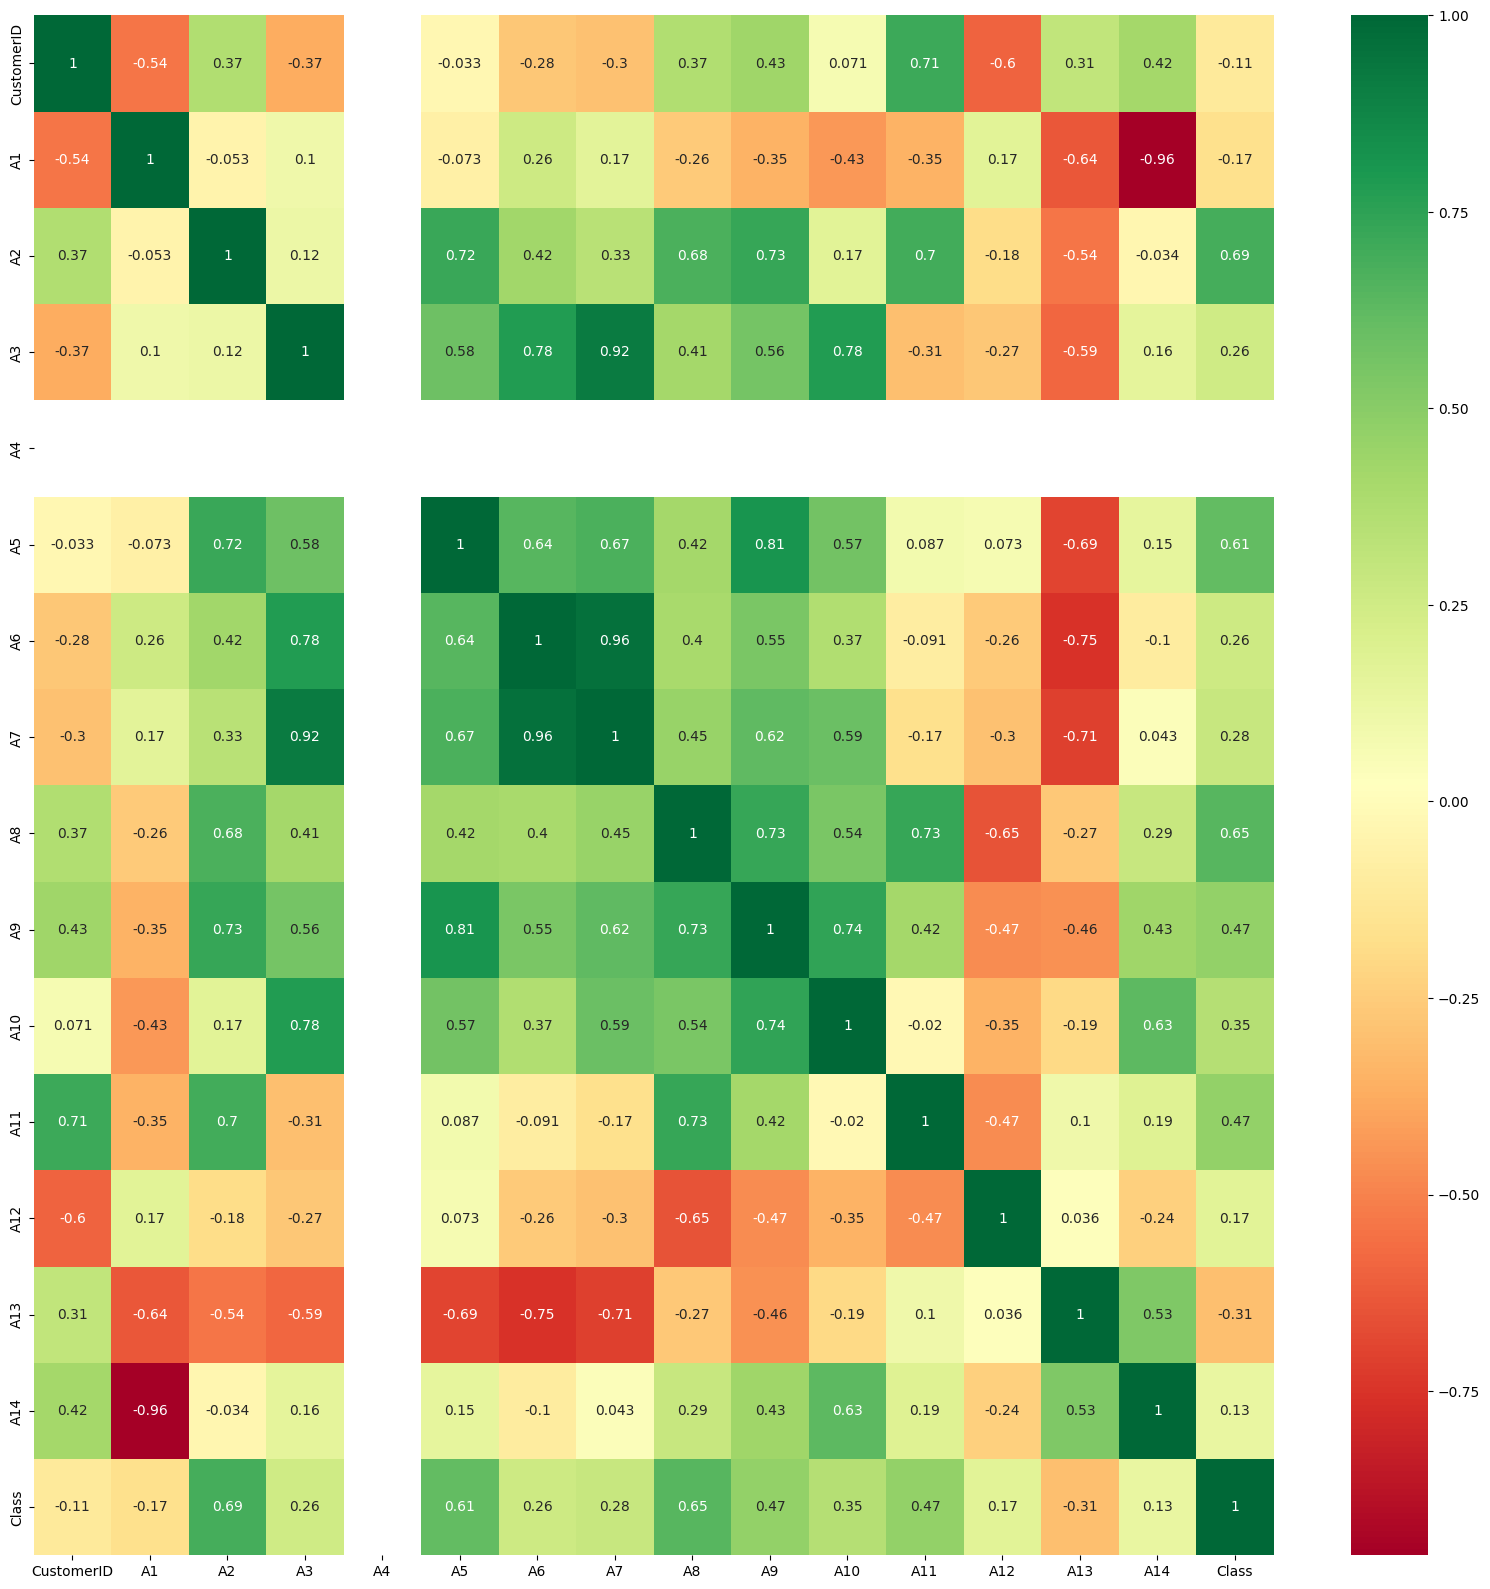

In [29]:
import seaborn as sns
#get correlations of each features in dataset
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [31]:
columns=data.columns.tolist()
columns=[c for c in columns if c not in ["Class"]]
target="Class"
state=np.random.RandomState(42)
X=data[columns]
Y=data[target]
X_outliners=state.uniform(low=0,high=1,size=(X.shape[0],X.shape[1]))
print(X.shape)
print(Y.shape)

(7, 15)
(7,)


In [33]:
classifiers = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        max_samples=len(X),
        # Original: contamination=outlier_fraction,
        # Fix: outlier_fraction (6.0) is out of IsolationForest's valid range (0.0, 0.5].
        # Using a default reasonable contamination value for demonstration.
        contamination=0.1,
        random_state=state,
        verbose=0
    ),
    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        algorithm='auto',
        leaf_size=30,
        metric='minkowski',
        p=2,
        metric_params=None,
        # Original: contamination=outlier_fraction
        # Fix: outlier_fraction (6.0) is out of LocalOutlierFactor's valid range (0.0, 0.5].
        # Using a default reasonable contamination value for demonstration.
        contamination=0.1
    )
}

type(classifiers)

n_outliers = len(Fraud)

for i, (clf_name, clf) in enumerate(classifiers.items()):
    # Fit the data and tag outliers
    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
        scores_prediction = clf.negative_outlier_factor_
    else:
        clf.fit(X)
        scores_prediction = clf.decision_function(X)
        y_pred = clf.predict(X)
    # Reshape the prediction values to 0 for Valid transactions, 1 for Fraud transactions
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1
    n_errors = (y_pred != Y).sum()
    # Run Classification Metrics
    print("{}: {}".format(clf_name, n_errors))
    print("Accuracy Score :")
    print(accuracy_score(Y, y_pred))
    print("Classification Report :")
    print(classification_report(Y, y_pred))

Isolation Forest: 5
Accuracy Score :
0.2857142857142857
Classification Report :
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.17      0.29         6

    accuracy                           0.29         7
   macro avg       0.58      0.58      0.29         7
weighted avg       0.88      0.29      0.29         7

Local Outlier Factor: 5
Accuracy Score :
0.2857142857142857
Classification Report :
              precision    recall  f1-score   support

           0       0.17      1.00      0.29         1
           1       1.00      0.17      0.29         6

    accuracy                           0.29         7
   macro avg       0.58      0.58      0.29         7
weighted avg       0.88      0.29      0.29         7



/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_lof.py:282: UserWarning: n_neighbors (20) is greater than the total number of samples (7). n_neighbors will be set to (n_samples - 1) for estimation.
  warnings.warn(
